# volkit — Demo Notebook

This notebook demonstrates the full volkit pipeline, from fetching real market data to computing the variance risk premium signal.

---
## 1. Setup

In [1]:
from volkit import market_data
from volkit.black_scholes import bs_price, greeks
from volkit.iv_surface import plot_surface, build_iv_surface, implied_volatility as iv_solver
from volkit.vol_spread import analyze_vol_spread, atm_implied_vol
from volkit.market_data.providers.yahoo import YahooProvider

from datetime import datetime
import pandas as pd
import numpy as np
import yfinance as yf

provider = YahooProvider()


---
## 2. Market Data

The market_data module fetches options chains and price history from multiple providers.
A single call to get_market_snapshot() returns everything needed to start the analysis.

In [2]:
# fetch spot price, 1 year of price history, and full options chain in one call
snapshot = market_data.get_market_snapshot(
    "SPY",
    expiry_from="2026-05-01",
    expiry_to="2026-12-31"
)

spot          = snapshot["spot"]
price_history = snapshot["price_history"]
options       = snapshot["options"]
expiries      = snapshot["expiries"]

print(f"Expiries: {expiries}")

  Spot price    : $709.17
  Price bars    : 251
  Options rows  : 4193
  Expiries      : 15
Expiries: ['2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-12-18', '2026-12-31']


In [3]:
# price history — daily OHLCV bars
price_history.tail()

,open,high,low,close,volume
Date,,,,,
2026-04-14,687.690002,694.580017,687.659973,694.460022,63480500
2026-04-15,695.260010,700.280029,694.200012,699.940002,58240400
2026-04-16,701.059998,702.780029,698.530029,701.659973,49972400
2026-04-17,706.140015,712.390015,705.760010,710.140015,70538900
2026-04-20,708.780029,709.909973,708.229980,709.169983,8730274


In [4]:
# options chain — bid, ask, mid, IV for every strike and expiry - Greeks are available via MarketData.app provider

options.head(10)

,strike,bid,ask,last,open_interest,volume,implied_volatility,option_type,expiry,mid
2184,400.0,308.69,311.44,310.61,29,29.0,1.494631,call,2026-05-01,310.065
2185,500.0,209.14,211.52,200.79,17,3.0,1.007573,call,2026-05-01,210.330
2186,510.0,199.17,201.52,200.98,6,6.0,0.960205,call,2026-05-01,200.345
2187,520.0,188.86,191.63,162.65,5,3.0,0.897950,call,2026-05-01,190.245
2188,530.0,178.75,181.63,110.30,26,26.0,0.842775,call,2026-05-01,180.190
2189,535.0,173.89,176.66,159.52,16,3.0,0.830812,call,2026-05-01,175.275
2190,540.0,169.23,171.60,141.59,7,1.0,0.824465,call,2026-05-01,170.415
2191,555.0,153.92,156.70,154.56,6,3.0,0.741946,call,2026-05-01,155.310
2192,560.0,148.87,151.71,150.25,25,21.0,0.716800,call,2026-05-01,150.290
2193,565.0,143.94,146.72,146.08,7,1.0,0.698489,call,2026-05-01,145.330


---
## 3. Black-Scholes Pricing

The black_scholes module prices European options and computes all five Greeks with no external pricing libraries.

Given five inputs — spot (S), strike (K), time to expiry (T), risk-free rate (r), volatility (sigma) — it returns the theoretical price and sensitivities.

In [5]:
from volkit.utils import get_risk_free_rate

# price a call option using Black-Scholes
S     = spot
K     = round(spot / 5) * 5   # nearest $5 strike to ATM
T     = 30 / 365              # 30 days to expiry
r     = get_risk_free_rate()  # risk-free rate
sigma = 0.18                  # assumed volatility

call_price = bs_price(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")
put_price  = bs_price(S=S, K=K, T=T, r=r, sigma=sigma, option_type="put")

print(f"Call price: ${call_price:.2f}")
print(f"Put price: ${put_price:.2f}")

Call price: $15.23
Put price: $13.96


In [6]:
# compute all five Greeks in one call
g = greeks(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")

print("Greeks (call):")
print(f"Delta : {g['delta']:+.4f}  — price change per $1 move in spot")
print(f"Gamma : {g['gamma']:+.4f}  — rate of change of delta")
print(f"Vega  : {g['vega']:+.4f}  — price change per 1% move in vol")
print(f"Theta : {g['theta']:+.4f}  — daily time decay")
print(f"Rho   : {g['rho']:+.4f}  — sensitivity to interest rates")

Greeks (call):
Delta : +0.5241  — price change per $1 move in spot
Gamma : +0.0109  — rate of change of delta
Vega  : +0.8096  — price change per 1% move in vol
Theta : -0.2781  — daily time decay
Rho   : +0.2930  — sensitivity to interest rates


---
## 4. Implied Volatility Solver

The IV solver inverts Black-Scholes using Newton-Raphson iteration — given a market price, it finds the volatility that makes the theoretical price match.

We compare our solver to the IV values provided by Yahoo Finance.

In [14]:
# get first monthly expiry (> 30 days)
target_expiry = next(
    e for e in sorted(options["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
)
T_exp = (datetime.strptime(target_expiry, "%Y-%m-%d") - datetime.today()).days / 365
T_exp

0.08493150684931507

In [ ]:
# sample 5 strikes around ATM
df = options[options["expiry"] == target_expiry].copy()
df["distance"] = abs(df["strike"] - spot)
sample = df.sort_values("distance").head(10)  # top 10 rows closest to spot

print(f"Expiry: {target_expiry}      T={T_exp:.3f}y      Spot=${spot:.1f}")
print(f"{'Strike':>8} {'Type':>6} {'Mid':>8} {'Our IV':>10} {'Yahoo IV':>10} {'Diff':>8}")

for _, row in sample.iterrows():
    our_iv   = iv_solver(row["mid"], spot, row["strike"], T_exp, r="market", option_type=row["option_type"])
    yahoo_iv = row["implied_volatility"]
    if our_iv and not pd.isna(our_iv) and not pd.isna(yahoo_iv):
        diff = our_iv*100 - yahoo_iv*100
        print(f"{row['strike']:>8.0f} {row['option_type']:>6} {row['mid']:>8.2f} "
              f"{our_iv*100:>9.1f}% {yahoo_iv*100:>9.1f}% {diff:>+7.1f}%")

Expiry: 2026-05-22      T=0.085y      Spot=$709.2
  Strike   Type      Mid     Our IV   Yahoo IV     Diff
     709   call    15.00      16.8%      17.6%    -0.9%
     709    put    11.62      15.5%      13.8%    +1.7%
     710   call    14.37      16.6%      17.4%    -0.8%
     710    put    12.02      15.4%      13.7%    +1.7%
     708    put    11.27      15.6%      14.0%    +1.7%
     708   call    15.59      16.8%      17.8%    -0.9%
     711    put    12.43      15.3%      13.5%    +1.8%
     711   call    13.75      16.5%      17.2%    -0.7%
     707    put    10.91      15.8%      14.1%    +1.6%
     707   call    16.31      17.1%      18.0%    -1.0%


---
## 5. Implied Volatility Surface

The IV surface shows how implied volatility varies across strikes and expiries.

Two key features to look for:
- **Volatility skew** — OTM puts (left side) trade at higher IV than OTM calls (right side)
- **Term structure** — how IV changes as expiry gets further out

In [ ]:
# filter to monthly expiries for a clean surface
monthly_expiries = [
    e for e in sorted(options["expiry"].unique())
    if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30
][:6]

options_monthly = options[options["expiry"].isin(monthly_expiries)]

# build the IV surface
surface = build_iv_surface(options_monthly, spot=spot)

print(f"{len(surface)} points - {len(surface['expiry'].unique())} expiries")
print(f"IV range: {surface['iv'].min()*100:.1f}% — {surface['iv'].max()*100:.1f}%")
print(f"Strike range: {surface['strike'].min():.0f} — {surface['strike'].max():.0f}")

282 points - 6 expiries
IV range: 13.1% — 21.8%
Strike range: 655 — 755


In [27]:
# verify the volatility skew — puts OTM should have higher IV than calls OTM
exp    = monthly_expiries[0]
surf_e = surface[surface["expiry"] == exp]

puts_otm  = surf_e[surf_e["strike"] < spot - 10].sort_values("strike", ascending=False).head(5)
calls_otm = surf_e[surf_e["strike"] > spot + 10].sort_values("strike").head(5)

print(f"Volatility skew — {exp} (Spot: ${spot:.0f})")
print(f"\nOTM Puts (strike < spot):")
for _, r in puts_otm.iterrows():
    print(f"  Strike {r['strike']:.0f}  →  IV {r['iv']*100:.1f}%")
print(f"\nOTM Calls (strike > spot):")
for _, r in calls_otm.iterrows():
    print(f"  Strike {r['strike']:.0f}  →  IV {r['iv']*100:.1f}%")

Volatility skew — 2026-05-22 (Spot: $709)

OTM Puts (strike < spot):
  Strike 699  →  IV 16.8%
  Strike 698  →  IV 17.0%
  Strike 697  →  IV 17.1%
  Strike 696  →  IV 17.3%
  Strike 695  →  IV 17.4%

OTM Calls (strike > spot):
  Strike 720  →  IV 15.4%
  Strike 725  →  IV 14.8%
  Strike 730  →  IV 14.4%
  Strike 735  →  IV 14.0%


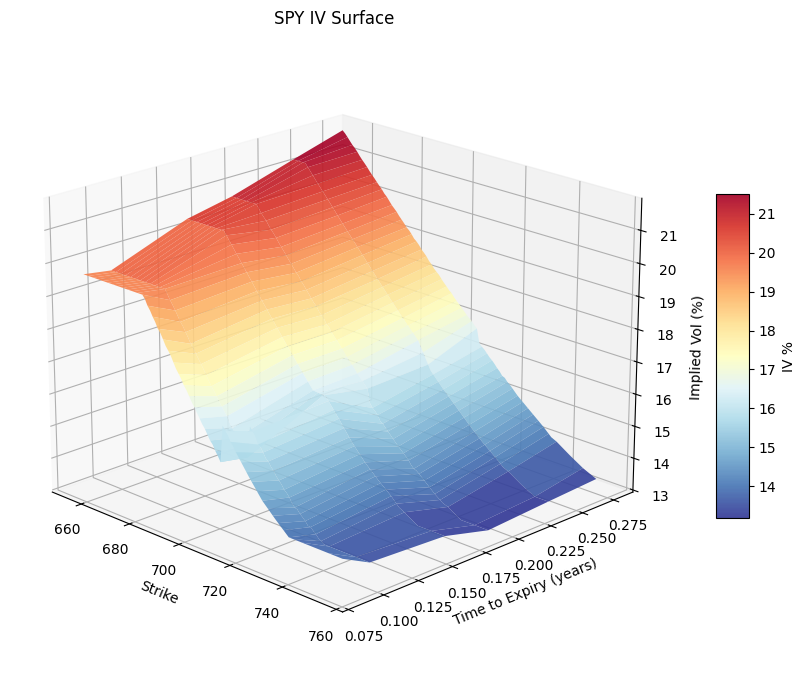

In [ ]:
# plot the IV surface
plot_surface(options_monthly, spot=spot, title="SPY IV Surface")

---
## 6. Vol Spread — Variance Risk Premium

The vol spread compares implied volatility to rolling realized volatility.
When IV > RV persistently, options are overpriced — the signal to sell volatility.

**IV Time Series**

Yahoo Finance does not provide historical options chains, so we use VIX as a proxy for historical IV. We compute the basis — the systematic difference between our solver and VIX today — and apply it as a correction to the full VIX history:

    basis          = our_IV_today - VIX_today
    IV_adjusted(t) = VIX(t) + basis
    spread(t)      = IV_adjusted(t) - RV(t)

  VIX today         : 17.5%
  Our ATM IV today  : 16.1%
  Basis             : -1.4%
------------------------------------------------------------
SPY Vol Spread Analysis
  Realized Vol (21d) : 18.6%
  Current Spread    : -2.5%
  Vol rich          : 94% of the time
  Regime            : CHEAP — vol underpriced, consider buying


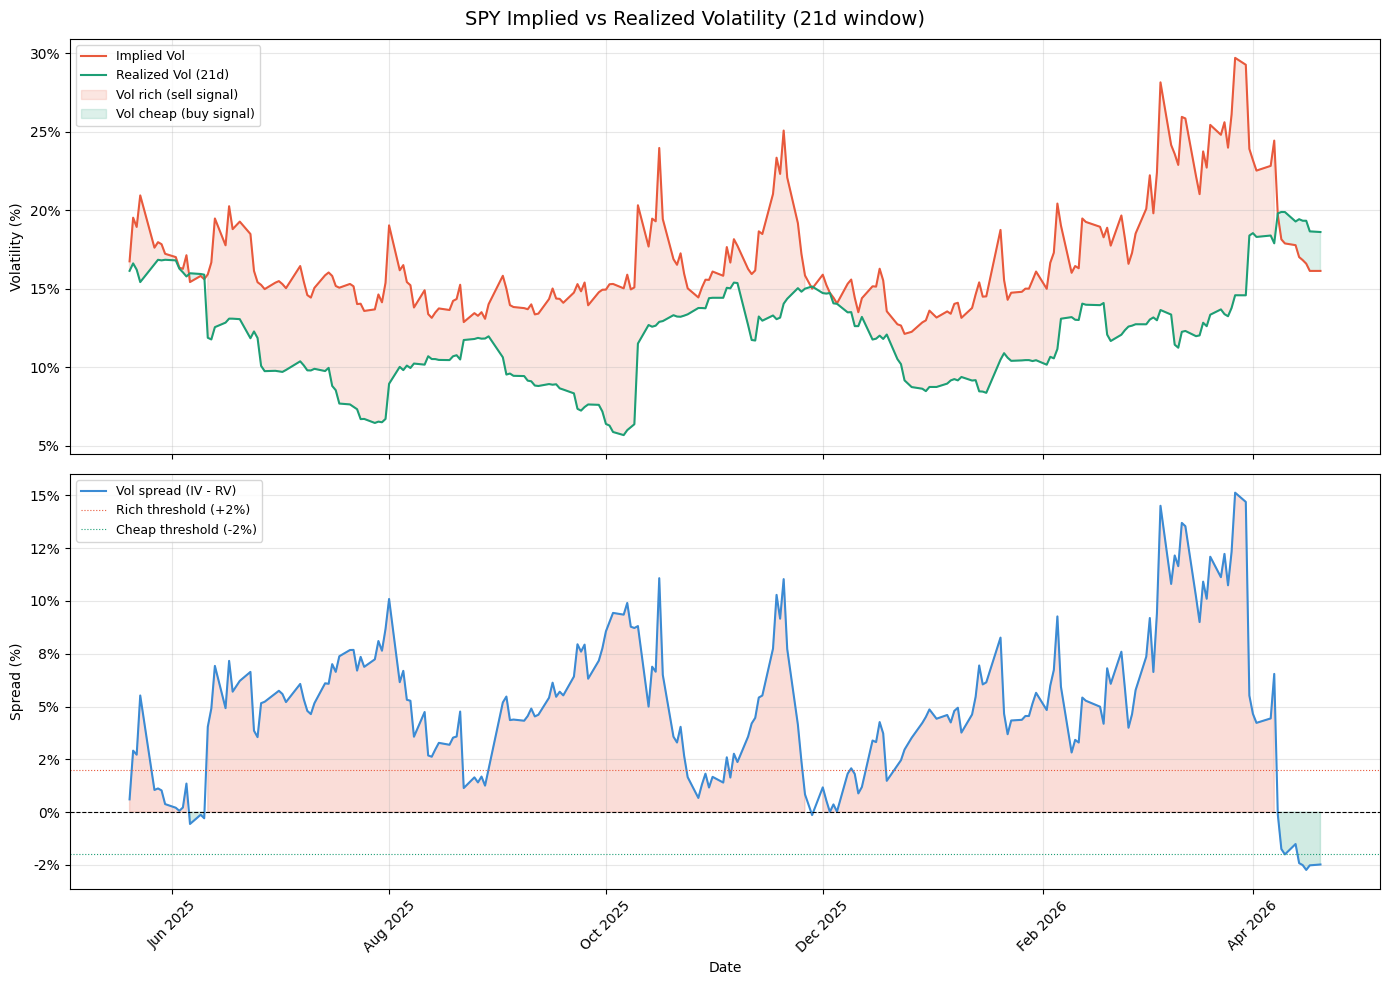

In [35]:
# full vol spread analysis — prints summary and plots both panels
spread_df = analyze_vol_spread(
    price_history=price_history,
    options=options,
    spot=spot,
    ticker="SPY",
    window=21,
    expiry=target_expiry,
    mode="vix_adjusted",
    rich_threshold=0.02,
    use_solver=True
)

In [ ]:
# the underlying DataFrame — IV, RV, and spread for every trading day
spread_df.tail(10)

,close,realized_vol,implied_vol,spread
Date,,,,
2026-04-06,658.929993,0.183788,0.22051,0.036722
2026-04-07,659.219971,0.178822,0.23661,0.057788
2026-04-08,676.010010,0.197896,0.18921,-0.008686
2026-04-09,679.909973,0.198797,0.17371,-0.025087
2026-04-10,679.460022,0.198748,0.17111,-0.027638
2026-04-13,686.099976,0.192733,0.17001,-0.022723
2026-04-14,694.460022,0.194184,0.16241,-0.031774
2026-04-15,699.940002,0.193203,0.16051,-0.032693
2026-04-16,701.659973,0.193200,0.15821,-0.034990


---
## 7. Cross-Ticker Comparison

ATM implied volatility varies significantly across tickers — single stocks always have higher IV than diversified indices.

In [38]:
vix   = yf.Ticker("^VIX").history(period="1d")["Close"].iloc[-1]
tickers = ["SPY", "AAPL", "NVDA"]

for ticker in tickers:
    snap = market_data.get_market_snapshot(ticker)
    s    = snap["spot"]
    opts = snap["options"]

    target = next(
        (e for e in sorted(opts["expiry"].unique())
         if (datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days > 30),
        sorted(opts["expiry"].unique())[3]
    )

    iv    = atm_implied_vol(opts, s, expiry=target, use_solver=True)
    basis = iv*100 - vix

    print(f"{ticker:<8} ${s:>7.1f} {iv*100:>9.1f}% {vix:>7.1f}% {basis:>+7.1f}%  {target}")


  Spot price    : $707.58
  Price bars    : 251
  Options rows  : 8621
  Expiries      : 33
SPY      $  707.6      16.5%    19.4%    -2.9%  2026-05-22
  Spot price    : $272.31
  Price bars    : 251
  Options rows  : 2156
  Expiries      : 24
AAPL     $  272.3      29.6%    19.4%   +10.2%  2026-05-22
  Spot price    : $199.12
  Price bars    : 251
  Options rows  : 3703
  Expiries      : 25
NVDA     $  199.1      40.8%    19.4%   +21.4%  2026-05-22


---
## 8. Historical Analysis

Using vix_raw mode we can analyze the variance risk premium over any historical period.
This uses real VIX data for each day — no basis adjustment needed.

------------------------------------------------------------
SPY 2024 Vol Spread Analysis
  Realized Vol (21d) : 14.4%
  Current Spread    : +3.0%
  Vol rich          : 90% of the time
  Regime            : RICH — vol expensive, consider selling


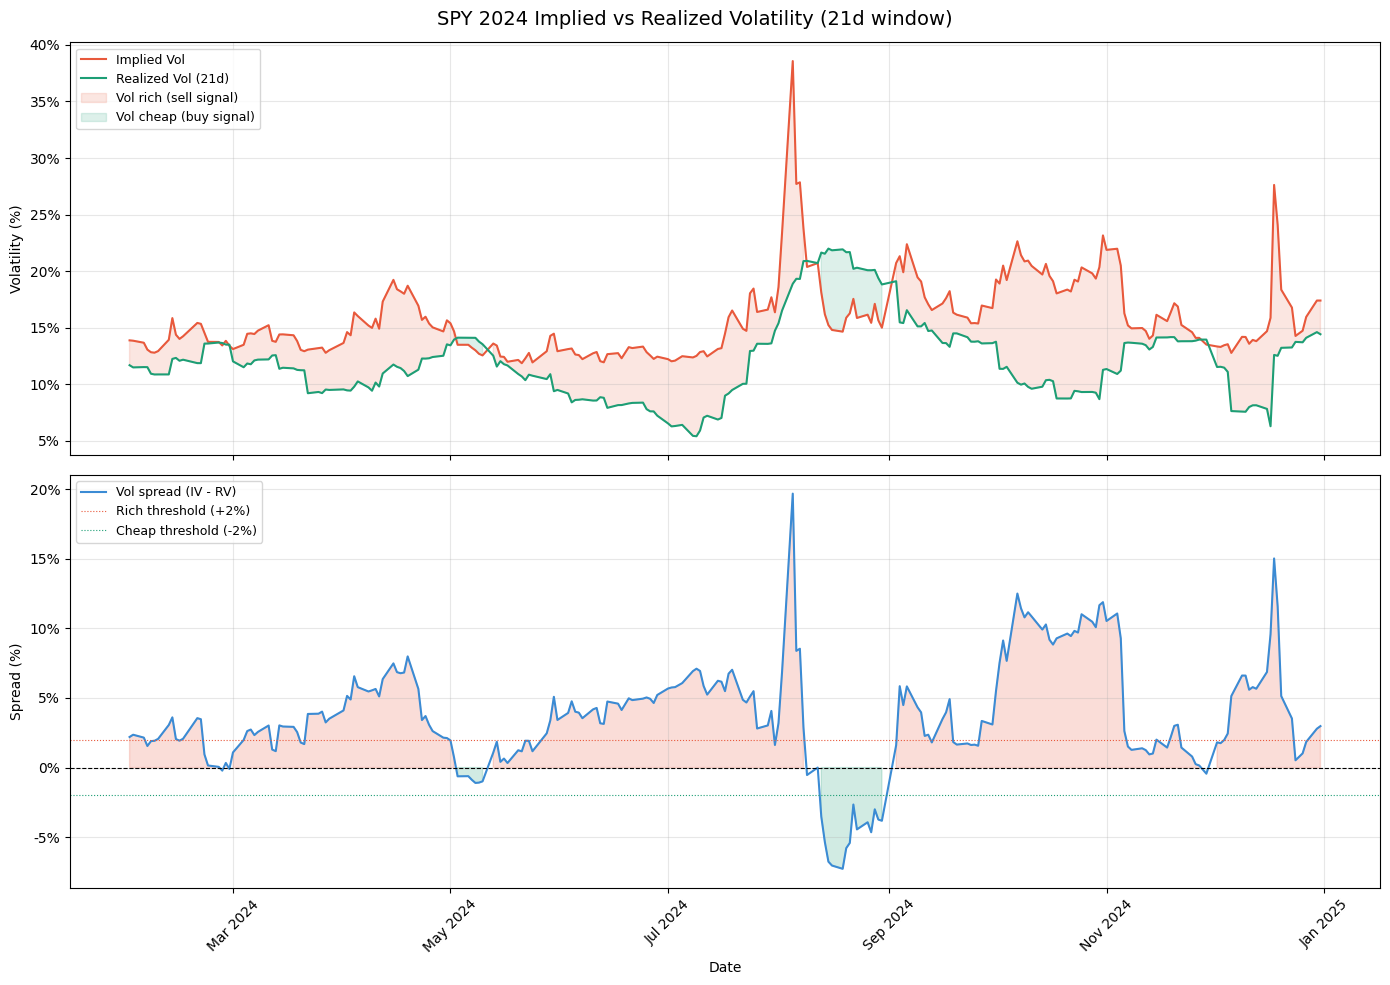

,close,realized_vol,implied_vol,spread
Date,,,,
2024-02-01,476.097992,0.116818,0.1388,0.021982
2024-02-02,481.110016,0.114894,0.1385,0.023606
2024-02-05,479.358276,0.115169,0.1367,0.021531
2024-02-06,480.749969,0.115100,0.1306,0.015500
2024-02-07,484.759613,0.109301,0.1283,0.018999
...,...,...,...,...
2024-12-24,592.702087,0.137460,0.1427,0.005240
2024-12-26,592.741638,0.137099,0.1473,0.010201
2024-12-27,586.502075,0.141067,0.1595,0.018433


In [ ]:
# analyze the vol spread during 2024
price_history_2024 = provider.get_price_history("SPY", start="2024-01-01", end="2025-01-01")

analyze_vol_spread(
    price_history=price_history_2024,
    options=options,
    spot=spot,
    ticker="SPY 2024",
    window=21,
    mode="vix_raw",
    rich_threshold=0.02,
)

---
## Summary

volkit implements the full variance risk premium pipeline:

| Step | Module | What it does |
|------|--------|--------------|
| 1 | market_data | Fetch real option prices and price history |
| 2 | black_scholes | Price options and compute Greeks from scratch |
| 3 | iv_surface | Extract IV via Newton-Raphson, build 3D surface |
| 4 | vol_spread | Compute IV − RV spread, identify RICH / CHEAP regimes |

github.com/fedecarz/volkit